In [5]:
import json
import pandas as pd

In [2]:
with open("../../data/meta_Appliances.jsonl","r") as f:
    first_line = json.loads(f.readline())

In [3]:
first_line

{'main_category': 'Industrial & Scientific',
 'title': 'ROVSUN Ice Maker Machine Countertop, Make 44lbs Ice in 24 Hours, Compact & Portable Ice Maker with Ice Basket for Home, Office, Kitchen, Bar (Silver)',
 'average_rating': 3.7,
 'rating_number': 61,
 'features': ['【Quick Ice Making】This countertop ice machine creates crystal & bullet shaped ice cubes; 44lbs of ice ready in 24 hours, 12 cubes made per cycle within 10 mins; you can perfectly use it for drinks, wine, smoothies, food',
  '【Portable Design】The weight of this ice maker is only 23.3lbs, and the small size (10.63 x14.37 x 12.87)" makes it portable. It\'s compact feature is perfect for home, office, apartments, dormitories, RVs and more, it can be placed on countertop or tabletop, plug it anywhere you like',
  '【Simple Operation】Adding the water tank with purified water; Power on machine and press "on/off" button to start ice making process; After 8-12 minutes, ice cube will fall off into the ice basket automatically; Take 

Filter items tha have been observed for first time in 2022

In [4]:
def filter_data(data:dict)->dict:
    filter = False
    if(int(data['details']['Date First Available'][-4:]) < 2022):
        filter = True
    return filter


In [10]:
import json



with open("../../data/meta_Appliances.jsonl","r") as fp:
    with open("../../data/meta_Appliances_2022_2023.jsonl","a",encoding='utf-8') as fp_out:
        with open("../../data/meta_Appliciances_2022_2023_no_date.jsonl","a",encoding='utf-8') as fp_out_no_date:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter = filter_data(data)
                    if not filter:
                        json.dump(data,fp_out)
                        fp_out.write("\n")
                        fp_out.flush()
                except:
                    json.dump(data,fp_out_no_date)
                    fp_out_no_date.write("\n")
                    fp_out_no_date.flush()
                i += 1
                if i % 1000 == 0:
                    print(f"processed {i} lines")


processed 1000 lines
processed 2000 lines
processed 3000 lines
processed 4000 lines
processed 5000 lines
processed 6000 lines
processed 7000 lines
processed 8000 lines
processed 9000 lines
processed 10000 lines
processed 11000 lines
processed 12000 lines
processed 13000 lines
processed 14000 lines
processed 15000 lines
processed 16000 lines
processed 17000 lines
processed 18000 lines
processed 19000 lines
processed 20000 lines
processed 21000 lines
processed 22000 lines
processed 23000 lines
processed 24000 lines
processed 25000 lines
processed 26000 lines
processed 27000 lines
processed 28000 lines
processed 29000 lines
processed 30000 lines
processed 31000 lines
processed 32000 lines
processed 33000 lines
processed 34000 lines
processed 35000 lines
processed 36000 lines
processed 37000 lines
processed 38000 lines
processed 39000 lines
processed 40000 lines
processed 41000 lines
processed 42000 lines
processed 43000 lines
processed 44000 lines
processed 45000 lines
processed 46000 lin

Splitting the items into two categories "has main category", "does not have main category"

In [14]:
def filter_category(data:dict)->dict:
    filter = False
    if(data['main_category'] == None):
        filter = True
    return filter


In [15]:
with open("../../data/meta_Appliances_2022_2023.jsonl","r") as fp:
    with open("../../data/meta_Appliances_2022_2023_with_category.jsonl","a",encoding='utf-8') as fp_out:
        with open("../../data/meta_Appliances_2022_2023_no_category.jsonl","a",encoding='utf-8') as fp_out_no_category:
            i=0
            for line in fp:
                data = json.loads(line.strip())
                if not filter_category(data):
                    json.dump(data,fp_out)
                    fp_out.write("\n")
                    fp_out.flush()
                else:
                    json.dump(data,fp_out_no_category)
                    fp_out_no_category.write("\n")
                    fp_out_no_category.flush()

Distribution of data by categories

In [6]:
df = pd.read_json("../../data/meta_Appliances_2022_2023_with_category.jsonl",lines=True)

In [7]:
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,Tools & Home Improvement,154567702 Dishwasher Lower Wash Arm Assembly f...,4.5,26,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,[MODEL NUMBER:154567702 Dishwasher Lower Wash ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],folosem,"[Appliances, Parts & Accessories, Dryer Parts ...","{'Manufacturer': 'folosem', 'Part Number': '15...",B0C7K98JZS,NaN
1,Tools & Home Improvement,WP67003405 67003405 Door Pivot Block - Compati...,4.1,4,[WP67003405 Pivot Block For Vernicle Mullion S...,[],16.52,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'High-Quality Items for a Fast DIY ...,PartsBroz,"[Appliances, Parts & Accessories]","{'Manufacturer': 'PartsBroz', 'Part Number': '...",B09QT3TJBZ,NaN
2,Amazon Home,MLGB Stainless Steel Brushed Pattern Dishwashe...,3.3,22,[Material: Our dishwasher stickers are made of...,[Stainless Steel Brushed Pattern Magnetic Dish...,38.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Dishwasher Cover 2021', 'url': 'ht...",MLGB,"[Appliances, Parts & Accessories, Dishwasher P...","{'Product Dimensions': '23 x 26 x 2 inches', '...",B09XXFX5SK,NaN
3,Tools & Home Improvement,Dryer Heating Element Replace For Maytag Bravo...,3.3,9,[Package included: All Dryer Electric Heating ...,[],36.95,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Dryer Heating Element Replace For ...,AZ4U,"[Appliances, Parts & Accessories, Dryer Parts ...","{'Manufacturer': 'MEDB400VQ0', 'Part Number': ...",B0BC1BPL8P,NaN
4,Amazon Home,HERISUN 100 Disposable Coffee Filters for Sing...,4.4,360,[【Good Fits in All Refillable Pods】K cup paper...,[],7.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],HERISUN,"[Small Appliance Parts & Accessories, Coffee &...",{'Product Dimensions': '4.7 x 2.5 x 2.5 inches...,B0BJKNMKRP,NaN


In [ ]:
import matplotlib as pt

Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='main_category'>

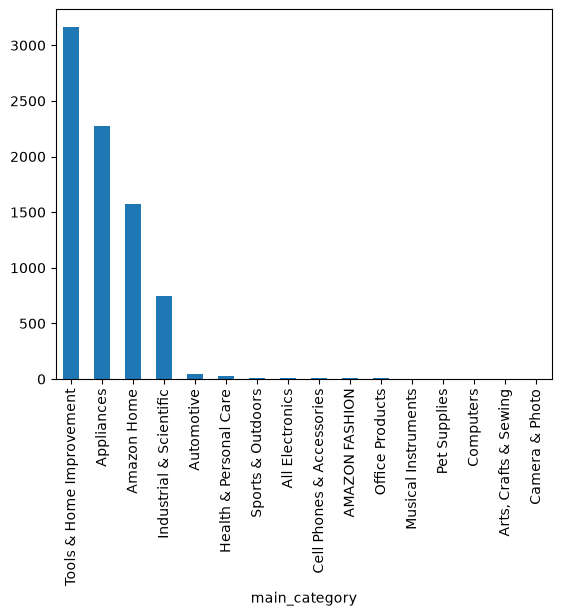

In [10]:
df['main_category'].value_counts().plot(kind='bar')

Filter out items that have atleast 100 ratings

In [11]:
df_ratings_100 = df[df['rating_number'] > 100]

In [12]:
len(df)

7888

In [13]:
len(df_ratings_100)

757

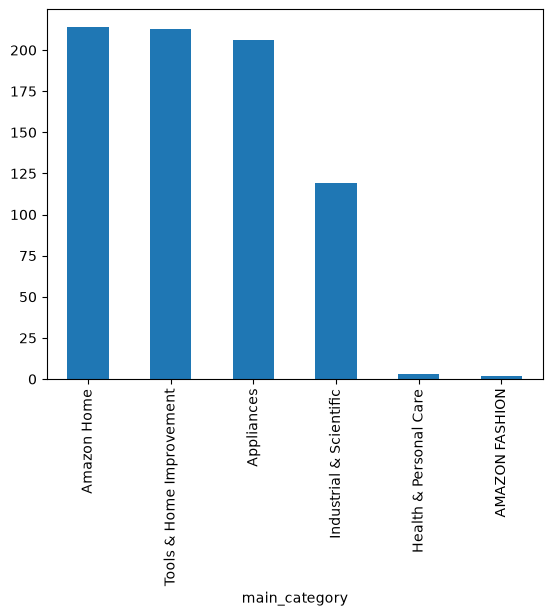

In [14]:
df_reduced = df_ratings_100['main_category'].value_counts().plot(kind='bar')

Explore distribution of ratings

<Axes: ylabel='Frequency'>

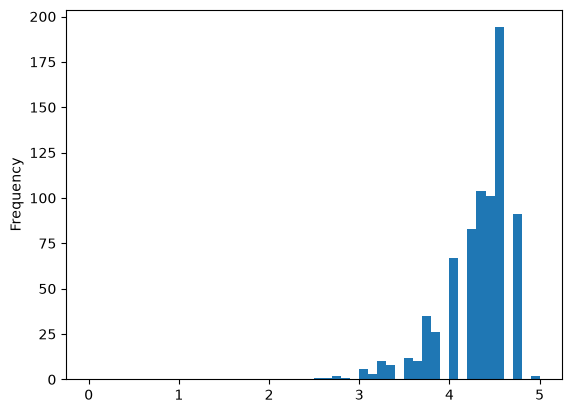

In [15]:
df_ratings_100['average_rating'].plot(kind='hist',bins=50,range=(0,5))

In [16]:
df_ratings_100.to_json("../../data/meta_Appliances_with_category_ratings_100.jsonl",orient='records',lines=True)

Extract ratings that match sampled data

In [18]:
df_ratings_100=pd.read_json("../../data/meta_Appliances_with_category_ratings_100.jsonl",lines=True)

In [19]:
with open('../../data/meta_Appliances.jsonl',"r") as fp:
    with open('../../data/meta_Appliances_with_category_ratings_100.jsonl',"a") as fp_out:
        id_list= set(df_ratings_100['parent_asin'].values)
        i=0
        for line in fp:
            data = json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data,fp_out)
                fp_out.write("\n")
                fp_out.flush()
            i += 1
            if i % 10000 == 0:
                print(f"Processed {i} lines")

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
